<a href="https://colab.research.google.com/github/paymantohidifar/protein-function-deep-learning/blob/main/notebooks/01_simple_mlp_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Protein Function Prediction Using a Simple MLP Model and ESM-2 Embeddings**

---

## **Table of Contents**

- [Environment Setup (Local or Google Colab)](#environment-setup-local-or-google-colab)
- [Introduction](#introduction)
- [Preparing the Datasets](#preparing-the-datasets)
  - [Downloading CAFA3 Data](#downloading-cafa3-data)
    - [Original CAFA3 Dataset](#original-cafa3-dataset)
    - [Preprocessed CAFA3 Dataset for DLFB](#preprocessed-cafa3-dataset-for-dlfb)
  - [Adding Human-readable GO Terms](#adding-human-readable-go-terms)
  - [Adding Protein Sequeces](#adding-protein-sequeces)
  - [Filtering Out Long Proteins](#filtering-out-long-proteins)
  - [Splitting the Dataset into Train/Validation/Test Sets](#splitting-the-dataset-into-trainvalidationtest-sets)
  - [Converting Protein Sequences to Their Mean Enbeddings](#converting-protein-sequences-to-their-mean-enbeddings)
- [Training a Multi-label Classifier Head](#training-a-multi-label-classifier-head)
  - [Training Workflow](#training-workflow)
  - [Evaluating the Model](#evaluating-the-model)
- [Examining Model Predictions](#examining-model-predictions)
  - [Thresholded and Continuous Evaluation Metrics](#thresholded-and-continuous-evaluation-metrics)
- [Evaluating Model Usefulness](#evaluating-model-usefulness)
- [Conducting a Final Check on the Test Set](#conducting-a-final-check-on-the-test-set)
- [Summary](#summary)

---

## **Environment Setup (Local or Google Colab)**

* Follow the **[instructions](../README.md)** to set up your local environment. If you are launching the notebook on VS Code, select a kernel associated with `pfdl`.
* The code block below automatically detects your execution runtime environment (Local vs. Google Colab) and if you're on Colab, it clones the repository, and installs all necessary dependencies.

> **Google Colab Note:** Once setup completes, navigate to **Runtime → Restart session** in the top menu before proceeding to the next steps to ensure all newly installed packages are correctly loaded.

In [1]:
import os
import subprocess
import sys

import torch

# Environment Detection: Check sys.modules for Colab runtime
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    print("Detected Google Colab environment. Initializing setup...")

    # Define paths
    branch = "main"
    repo_url = (
        "https://github.com/paymantohidifar/protein-function-deep-learning.git"
    )
    target_dir = "/content/pfdl"

    # Clean stale builds and clone main branch
    subprocess.run(f"rm -rf {target_dir}", shell=True, check=True)
    subprocess.run(
        f"git clone {repo_url} --branch {branch} {target_dir}",
        shell=True,
        check=True,
    )
    print("Cloned the repo.")

    # Change working directory
    os.chdir(target_dir)

    # Bootstrap uv and install dependencies into system environment
    install_cmd = (
        'curl -LsSf https://astral.sh/uv/install.sh | sh && '
        'export PATH="$HOME/.local/bin:${PATH}" && '
        'uv pip install -e .[cpu,dev] --system --break-system-packages --color never'
    )
    print("Installing dependencies...")
    subprocess.run(install_cmd, shell=True, check=True)
    print("Colab setup complete.")

else:
    # Local Development: Enable IPython Auto-Reload safely
    ipython = get_ipython()
    if ipython is not None:
        ipython.run_line_magic("load_ext", "autoreload")
        ipython.run_line_magic("autoreload", "2")
        print("Enabled IPython autoreload.")


# Verify PyTorch version and config
print(f"\nInstalled Pytorch version: {torch.__version__}")
print(f"PyTorch enabled with Cuda: {torch.cuda.is_available()}")

Enabled IPython autoreload.

Installed Pytorch version: 2.6.0+cpu
PyTorch enabled with Cuda: False


---

## **Introduction**

Our goal in this notebook is to build a simple neural network model to predict protein function from its amino acid sequence. We will use the [CAFA (Critical Assessment of Functional Annotation)](https://biofunctionprediction.org/cafa/) dataset as our primary resource and will conduct all necessary steps from data preparation, model training to model performance evaluation. In the end, we will briefly discuss potential options to improve model performance further.

---

## **Preparing the Datasets**

In this section, we will follow steps in the following workflow to turn raw biological data into a model-ready format:

1. **Sequence Standardization:** Cleaning and validating amino acid strings.
2. **Functional Mapping:** Associating sequences with hierarchical GO (Gene Ontology) terms.
3. **Vectorization:** Converting text-based sequences into numerical embeddings using models like ESM-2.
4. **Filtering:** Removing overly broad GO terms to ensure the model learns specific biological insights.

Note that the step-by-step approach above will ensure that when our model struggles, we have the intuition to identify whether the flaw lies in the learning process or the biological data itself.

### **Downloading CAFA3 Data**

There have been several rounds of [CAFA](https://biofunctionprediction.org/cafa/), but the CAFA3 dataset (2016-2017) is the most recent publicly available one. You can find more about CAFA3 [here](https://link.springer.com/article/10.1186/s13059-019-1835-8).

We will first download the “CAFA3 Targets” and “CAFA3 Training Data” files from the CAFA website.

Links to CAFA4 datasets (2019-2020) are currently broken on the source site. However, if you are interested in more recent datasets, [CAFA5](https://www.kaggle.com/c/cafa-5-protein-function-prediction) and [CAFA6](https://www.kaggle.com/competitions/cafa-6-protein-function-prediction/data?select=Train) are avialable through Kaggle competitions.

#### **Original CAFA3 Dataset**

In [2]:
# cafa3_train_data_url = "https://biofunctionprediction.org/cafa-targets/CAFA3_training_data.tgz"

#### **Preprocessed CAFA3 Dataset for DLFB**

In [3]:
from pfdl.paths import DATA_DIR
from pfdl.downloads import download_data

DATA_DLFB = DATA_DIR / "dlfb-version"
train_terms_fpath = DATA_DLFB / "train_terms.tsv.zip"
base_url = "https://assets.deep-learning-for-biology.com/proteins/datasets"

DATA_DLFB.mkdir(parents=True, exist_ok=True)
if train_terms_fpath.exists():
    print("File already exists! Skipping the download.")
else:
    download_data(base_url, "train_terms.tsv.zip", train_terms_fpath)

File already exists! Skipping the download.


In [4]:
import pandas as pd

labels = pd.read_csv(
    train_terms_fpath, sep='\t', compression='infer'
)

print(labels.shape)
labels.head()

(5363863, 3)


,EntryID,term,aspect
0,A0A009IHW8,GO:0008152,BPO
1,A0A009IHW8,GO:0034655,BPO
2,A0A009IHW8,GO:0072523,BPO
3,A0A009IHW8,GO:0044270,BPO
4,A0A009IHW8,GO:0006753,BPO


The dataframe above has three columns:
* **EntryID:** UniProt ID of the protein
* **term:** A GO accession code describing a specific protein function
* **aspect:** The GO category the function belongs to (e.g. biological process (BPO), molecular function (MFO), and cellular component (CCO))

### **Adding Human-readable GO Terms**

To make CAFA dataset more human-readable, we cross-reference GO terms using the official Gene Ontology library. For more details, check [this](https://geneontology.org/docs/download-go-annotations/) out.

We will use `obonet` Python library to parse `.obo` (Open Biomedical Ontology format) graph format to programmatically map each GO ID to its biological definition using `get_go_term_descriptions` helper fucntion:

In [5]:
from pfdl.data import get_go_term_descriptions

go_term_fpath = DATA_DLFB / "go_term_descriptions.zip"
obo_url = "https://current.geneontology.org/ontology/go-basic.obo"
go_term_descriptions = get_go_term_descriptions(obo_url, store_path=go_term_fpath)

File already exists. Parsing the file into dataframe.


In [6]:
# Preview thr go terms dataframe
print(go_term_descriptions.shape)
go_term_descriptions.head()

(38245, 2)


,term,description
0,GO:0000001,mitochondrion inheritance
1,GO:0000006,high-affinity zinc transmembrane transporter a...
2,GO:0000007,low-affinity zinc ion transmembrane transporte...
3,GO:0000009,"alpha-1,6-mannosyltransferase activity"
4,GO:0000010,heptaprenyl diphosphate synthase activity


We will add `description` columns to `labels` by merging the two dataframes on `term` column:

In [7]:
labels = labels.merge(go_term_descriptions, on='term')

print(labels.shape)
labels.head()

(4861444, 4)


,EntryID,term,aspect,description
0,A0A009IHW8,GO:0008152,BPO,metabolic process
1,A0A009IHW8,GO:0034655,BPO,nucleobase-containing compound catabolic process
2,A0A009IHW8,GO:0072523,BPO,purine-containing compound catabolic process
3,A0A009IHW8,GO:0006753,BPO,nucleoside phosphate metabolic process
4,A0A009IHW8,GO:1901292,BPO,nucleoside phosphate catabolic process


We can see that we lost some of rows in the original labels dataframe because some of Entry IDs were missing in `go_term_descriptions` dataframe. We should be fine even losing some of the data.

In this work, we will focus on **Molecular Function** terms denoted as **MFO** on `aspect` column. Here is the example counts on each GO category:

In [8]:
print(labels.value_counts('aspect'))

aspect
BPO    3033627
CCO    1183004
MFO     644813
Name: count, dtype: int64


In [9]:
labels = labels[labels['aspect'] == "MFO"]

print(labels.shape)

(644813, 4)


To gain some insight about different types of Molecular Function GO terms, let's quickly examine their distributions:

In [10]:
labels.value_counts('description')

description
molecular_function                               78637
binding                                          57380
protein binding                                  47987
catalytic activity                               25324
heterocyclic compound binding                    12694
                                                 ...  
2-carboxy-D-arabinitol-1-phosphatase activity        1
geissoschizine dehydrogenase activity                1
parthenolide synthase activity                       1
parthenolide 3beta-hydroxylase activity              1
costunolide 3beta-hydroxylase activity               1
Name: count, Length: 6866, dtype: int64

As shown above, the distribution of protein function annotations is heavily skewed, dominated by generic terms like "molecular_function" and "binding." These high-frequency labels provide minimal biological insight and will be filtered out later to improve model performance.

#### **Adding Protein Sequeces**
To pair these labels with their respective biological data, we will dowload and load protein sequences from a FASTA file. Using the `BioPython.SeqIO` module, we can parse these sequences into a Pandas DataFrame for easier manipulation.

In [11]:
train_seq_fpath = DATA_DLFB / "train_sequences.fasta"
base_url = "https://assets.deep-learning-for-biology.com/proteins/datasets"

if train_seq_fpath.exists():
    print("File already exists! Skipping the download.")
else:
    download_data(base_url, "train_sequences.fasta", train_seq_fpath)

File already exists! Skipping the download.


In [12]:
from Bio import SeqIO

records = SeqIO.parse(open(train_seq_fpath), format='fasta')
sequence_df = pd.DataFrame(
    data=[(record.id, str(record.seq), len(record.seq)) for record in records],
    columns=["EntryID", "Sequence", "Length"]
)

print(sequence_df.shape)
sequence_df.head()

(142246, 3)


,EntryID,Sequence,Length
0,P20536,MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...,218
1,O73864,MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...,354
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258
3,A0A0B4J1F4,MGGEAGADGPRGRVKSLGLVFEDESKGCYSSGETVAGHVLLEAAEP...,415
4,P54366,MVETNSPPAGYTLKRSPSDLGEQQQPPRQISRSPGNTAAYHLTTAM...,415


The CAFA dataset includes proteins from many different organisms. In this notebook, we will focus on human proteins. To retrieve human proteins, we will use NCBI taxonomy ("Tax" for short) IDs associated with them. This information is available in `train_taxonomy.tsv.zip` file.

We need to download the file and add the Tax IDs to `sequence_df` and keep examples with Homo sapiens Tax ID **9606**.

In [13]:
train_tax_fpath = DATA_DLFB / "train_taxonomy.tsv.zip"
base_url = "https://assets.deep-learning-for-biology.com/proteins/datasets"

if train_tax_fpath.exists():
    print("File already exists! Skipping the download.")
else:
    download_data(base_url, "train_taxonomy.tsv.zip", train_tax_fpath)

File already exists! Skipping the download.


In [14]:
taxonomy = pd.read_csv(train_tax_fpath, sep='\t', compression='infer')

print(taxonomy.shape)
taxonomy.head()

(142246, 2)


,EntryID,taxonomyID
0,Q8IXT2,9606
1,Q04418,559292
2,A8DYA3,7227
3,Q9UUI3,284812
4,Q57ZS4,185431


In [15]:
sequence_df = sequence_df.merge(taxonomy, on='EntryID')

print(sequence_df.shape)
sequence_df.head()

(142246, 4)


,EntryID,Sequence,Length,taxonomyID
0,P20536,MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...,218,10249
1,O73864,MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...,354,7955
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606
3,A0A0B4J1F4,MGGEAGADGPRGRVKSLGLVFEDESKGCYSSGETVAGHVLLEAAEP...,415,10090
4,P54366,MVETNSPPAGYTLKRSPSDLGEQQQPPRQISRSPGNTAAYHLTTAM...,415,7227


In [16]:
sequence_df = sequence_df[sequence_df['taxonomyID'] == 9606]

print(sequence_df.shape)
sequence_df.head()

(25125, 4)


,EntryID,Sequence,Length,taxonomyID
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606
5,P33681,MGHTRRQGTSPSKCPYLNFFQLLVLAGLSHFCSGVIHVTKEVKEVA...,288,9606
7,Q16787,MAAAARPRGRALGPVLPPTPLLLLVLRVLPACGATARDPGAAAGLS...,3333,9606
10,Q96S79,MVSTYRVAVLGARGVGKSAIVRQFLYNEFSEVCVPTTARRLYLPAV...,203,9606
14,Q5MNZ6,MNLLPCNPHGNGLLYAGFNQDHGCFACGMENGFRVYNTDPLKEKEK...,344,9606


We ended up with about 25K human proteins. Now, add Go terms on `labels` dataframe to our human `sequence_df` dataframe"

In [17]:
sequence_df = sequence_df.merge(labels, on='EntryID')

print(sequence_df.shape)

print(
    f"Dataset contains {sequence_df['EntryID'].nunique()} proteins with "
    f"{sequence_df['term'].nunique()} molecular functions."
)

(150308, 7)
Dataset contains 16336 proteins with 4037 molecular functions.


We can already see that many proteins are associated with multiple molecular functions. To quantify this, we examine the distribution of the number of functions per protein:

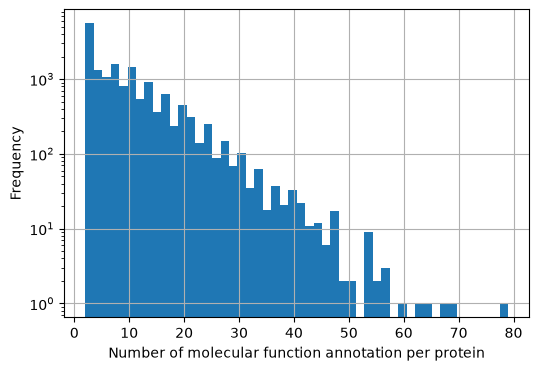

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
sequence_df.groupby('EntryID')['term'].nunique().hist(bins=50, log=True, ax=ax)
ax.set_xlabel("Number of molecular function annotation per protein")
ax.set_ylabel("Frequency");

The biological reality of protein "multitasking" means that many proteins perform multiple roles, acting as enzymes while simultaneously binding to other molecules. For machine learning, this creates two specific challenges: multi-label classification and extreme class imbalance (where some functions are rare and others are ubiquitous).

As we showed in an ealier step, broad terms like "molecular function" or "protein binding" are so universal that they provide almost no predictive value. To prevent the model from "cheating" by fixating on these dominant but generic labels, we must explicitly filter them out during preprocessing, forcing the model to learn more specific and meaningful biological functions.

In [19]:
print(sequence_df['description'].value_counts())

description
molecular_function                                       16336
binding                                                  15148
protein binding                                          14541
catalytic activity                                        3875
heterocyclic compound binding                             2943
                                                         ...  
BRE binding                                                  1
creatine:sodium symporter activity                           1
11-beta-hydroxysteroid dehydrogenase (NADP+) activity        1
acetylcholine receptor inhibitor activity                    1
(R)-2-hydroxyglutarate dehydrogenase activity                1
Name: count, Length: 4037, dtype: int64


In [20]:
# Retrieve top 3 generic functions
generic_functions = sequence_df['description'].value_counts().head(3).index.tolist()

# Remove examples associated with `generic functions`
sequence_df = sequence_df[~sequence_df['description'].isin(generic_functions)]

print(sequence_df.shape)

(104283, 7)


On the other hand, we see many molecular functions are exceptionally rare; for instance, BRE binding appears only a single time in the dataset.

To ensure the model learns statistically significant associations rather than noise, we must provide sufficient training examples for each functional category. We will keep the examples with molecular function associated with at least **50** distrinct proteins. Note that this number can be assumed to be a hyperparameter.

In [21]:
# Retrieve "GO terms" with at least 50 distict proteins
common_functions = sequence_df['term'].value_counts()[sequence_df['term'].value_counts() > 50].index

# Keep examples associated with `common_functions`
sequence_df = sequence_df[sequence_df['term'].isin(common_functions)]

print(sequence_df.shape)

# Verify
print(sequence_df['term'].value_counts())

(82440, 7)
term
GO:0003824    3875
GO:1901363    2943
GO:0003676    2469
GO:0042802    1803
GO:0016740    1652
              ... 
GO:0004714      52
GO:0005230      52
GO:0016835      52
GO:0005516      51
GO:0031490      51
Name: count, Length: 291, dtype: int64


We need to reshape our dataset to be able to separate features (e.g. sequence embeddings, length, etc) from targets (protein function or GO term) by transforming the categorical protein function annotations into a binary occurrence matrix, analogous to one-hot encoding.

We will ignore certain columns like `taxonomyID`, `aspect`, and `description` as they don't provide additional information.

In [22]:
# Keep important columns, add `value` column with 1's,
# pivot the table on `term` column
sequence_df_wide = (
    sequence_df[['EntryID', 'Sequence', 'Length', 'term']]
    .assign(value=1)
    .pivot(
        index=['EntryID', 'Sequence', 'Length'],
        columns='term',
        values='value'
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)

print(sequence_df_wide.shape)
sequence_df_wide.head()

(10705, 294)


term,EntryID,Sequence,Length,GO:0000166,GO:0000287,GO:0000976,GO:0000977,GO:0000978,GO:0000981,GO:0000987,...,GO:0140677,GO:0140678,GO:1901265,GO:1901363,GO:1901681,GO:1901702,GO:1901981,GO:1902936,GO:1990782,GO:1990837
0,A0A024R6B2,MIASCLCYLLLPATRLFRALSDAFFTCRKNVLLANSSSPQVEGDFA...,670,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,A0A087WUI6,MSRKISKESKKVNISSSLESEDISLETTVPTDDISSSEEREGKVRI...,698,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,A0A087X1C5,MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,515,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,A0A0C4DG62,MAHVGSRKRSRSRSRSRGRGSEKRKKKSRKDTSRNCSASTSQERSK...,218,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,A0A0C4DGF1,MSLPPIRLPSPYGSDRLVQLAARLRPALCDTLITVGSQEFPAHSLV...,302,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


This dataset is now in a format that’s almost ready for machine learning.

Before we move on, let’s run a few final sanity checks on (1) number of unique proteins (2) number of unique sequences:

In [23]:
print("Number of unique proteins:", sequence_df_wide['EntryID'].nunique())
print("Number of unique sequences:", sequence_df_wide['Sequence'].nunique())

Number of unique proteins: 10705
Number of unique sequences: 10694


The number of protein in 10,000 is in right ballpark. There are roughly 21,000 protein-coding genes in the human genome, and since we applied several filtering steps, we expect a somewhat smaller number. It’s always worth keeping rough order-of-magnitude expectations in mind—if we saw 1,000 or 1,000,000 here, we’d suspect something was off.

On the other hand, number of sequences is a little less than the number of proteins, suggesting some of the proteins have identical sequences.

#### **Filtering Out Long Proteins**

Downstream machine/deep learning models cannot directly ingest variable-length raw text representations of protein sequences. To bridge this gap, we need to project these sequences into continuous, dense numerical vector spaces using protein language models, such as ESM-2 (See [here](#converting-protein-sequences-to-their-mean-enbeddings)).

The self-attention engine in ESM-2 Transformer models scales quadratically in both memory consumption and computational complexity relative to the sequence length, $O(L^2)$, and long sequences can easily trigger Out-Of-Memory (OOM) errors during inference. Therefore, we need to apply an upper limit to our sequence array lengths.

But, what is a good length not to surpass our hardware limits and retain sufficient amount of data for training our model? We will find this out by visualizing the absolute sequence length distribution across our examples:

Median of length:  461.0
75% quantile of length:  723.0


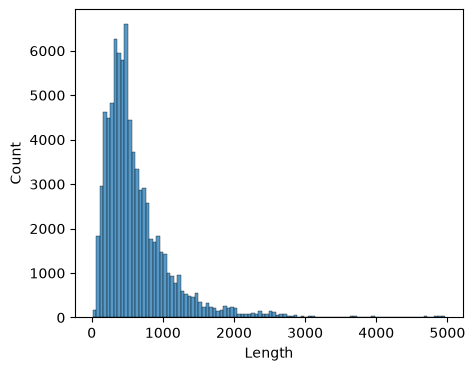

In [24]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 4))
sns.histplot(ax=ax, data=sequence_df[sequence_df['Length'] < 5000], x='Length', bins=100);

print("Median of length: ", sequence_df_wide['Length'].quantile(0.5))
print("75% quantile of length: ", sequence_df_wide['Length'].quantile(0.75))

Based on the figure and quantiles, maximum of 500 amino acids can be a good heuristic to start with:

In [25]:
sequence_df_wide = sequence_df_wide[sequence_df_wide['Length'] <= 500]
print(sequence_df_wide.shape)

(5955, 294)


We almost halved the dataset size which is perfectly fine for our initial prototyping.

### **Splitting the Dataset into Train/Validation/Test Sets**

To ensure reliable evaluation, we will partition our examples by `EntryID` into three mutually exclusive train (60%), validation (20%), and test (20%) subsets:

In [26]:
from sklearn.model_selection import train_test_split

train_seq_ids, valid_test_seq_id = train_test_split(
    list(set(sequence_df_wide['EntryID'])), test_size=0.4, random_state=42
)

valid_seq_ids, test_seq_ids = train_test_split(
    valid_test_seq_id, test_size=0.5, random_state=42
)

sequence_splits = {
    'train': sequence_df_wide[sequence_df_wide['EntryID'].isin(train_seq_ids)],
    'valid': sequence_df_wide[sequence_df_wide['EntryID'].isin(valid_seq_ids)],
    'test': sequence_df_wide[sequence_df_wide['EntryID'].isin(test_seq_ids)],
}

for subset, data in sequence_splits.items():
    print(f"{subset} has {len(data)} entries.")

train has 3573 entries.
valid has 1191 entries.
test has 1191 entries.


### **Converting Protein Sequences to Their Mean Enbeddings**

As we touched on sequence embeddings in the previous subsectiopn, we will use ESM-2 to generate rich representation of our protein sequences. Briefly, EMS-2 is trained via masked language modeling across millions of evolutionarily diverse sequences and leverages deeply stacked self-attention layers to generate contextualized representations that implicitly capture spatial structural topography and thermodynamic properties without requiring explicit 3D coordinates.

We will now convert the protein sequences from each split into their mean embeddings. To optimize this time-intensive process, we utilize two strategies: (1) optionally using a GPU to parallelize the transformer forward pass, (2) computing the embeddings once and saving them to disk (serialization) to avoid redundant computation in future sessions.

To streamline this, we will use two helper functions `store_sequence_embeddings` for storing and `load_sequence_embeddings` loading these high-dimensional vectors. `store_sequence_embeddings` utilize another helper function to return mean embedding for each sequence using a protein LM.

In [27]:
from transformers import AutoTokenizer, EsmModel
from pfdl.paths import MODELS_DIR
from pfdl.configs import get_esm_checkpoint


esm_checkpoint = get_esm_checkpoint("esm2-150M")
esm_tokenizer = AutoTokenizer.from_pretrained(esm_checkpoint, cache_dir=MODELS_DIR)
esm_model = EsmModel.from_pretrained(esm_checkpoint, cache_dir=MODELS_DIR)

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
from pfdl.data import store_sequence_embeddings

for split, df in sequence_splits.items():
    store_sequence_embeddings(
        sequence_df=df,
        store_prefix=str(DATA_DLFB / f"protein_dataset_{split}"),
        tokenizer=esm_tokenizer,
        model=esm_model,
    )

In [29]:
from pfdl.data import load_sequence_embeddings

train_df = load_sequence_embeddings(
    store_file_prefix=str(DATA_DLFB / "protein_dataset_train"),
    model_checkpoint=esm_checkpoint
)

print(train_df.shape)
train_df.head()

(3573, 934)


,EntryID,Sequence,Length,GO:0000166,GO:0000287,GO:0000976,GO:0000977,GO:0000978,GO:0000981,GO:0000987,...,ME:631,ME:632,ME:633,ME:634,ME:635,ME:636,ME:637,ME:638,ME:639,ME:640
0,A0A0C4DG62,MAHVGSRKRSRSRSRSRGRGSEKRKKKSRKDTSRNCSASTSQERSK...,218,0,0,0,0,0,0,0,...,0.119577,0.015741,0.251552,-0.129825,0.066691,0.065308,0.038825,0.029075,-0.029456,0.029301
1,A0A0C4DGF1,MSLPPIRLPSPYGSDRLVQLAARLRPALCDTLITVGSQEFPAHSLV...,302,0,0,0,0,0,0,0,...,0.019826,0.045979,-0.010875,-0.239983,-0.031418,0.079132,-0.051789,-0.040140,-0.043471,-0.088794
2,A0A1B0GTB2,MVITSENDEDRGGQEKESKEESVLAMLGIIGTILNLIVIIFVYIYTTL,48,0,0,0,0,0,0,0,...,0.156347,0.043921,0.140974,-0.031518,0.071298,0.131888,-0.045343,0.021990,-0.020959,0.127363
3,A0AVI4,MDSPEVTFTLAYLVFAVCFVFTPNEFHAAGLTVQNLLSGWLGSEDA...,362,0,0,0,0,0,0,0,...,0.048990,-0.070102,-0.422294,0.024710,-0.153485,0.158002,-0.074533,0.024345,-0.120066,0.024783
4,A0PJX0,MGQCLRYQMHWEDLEEYQALTFLTRNEILCIHDTFLKLCPPGKYYK...,185,0,1,0,0,0,0,0,...,0.117469,0.059133,0.086317,0.060061,-0.043633,0.060833,-0.086828,0.040075,-0.110137,0.004014


On `train_df`, we see a series of columns labeled `ME:1` through `ME:640`. These represent the **mean-pooled hidden states** from the last hidden layer of the ESM2 model, effectively a fixed-length numerical summary of each protein sequence. These embeddings capture biochemical and structural information learned during pretraining and will serve as the input features for our classifier.

We will use a custom PyTorch Dataset class `ProtDataset` as well as a helper function `create_data_loader` to prepare the datasets for each split. Here is an example for `train_df`:

In [30]:
from pfdl.data import create_data_loader

data_loader = create_data_loader(train_df, batch_size=32, is_training=True)
batch = next(iter(data_loader))
print(batch['embedding'].shape, batch['target'].shape)

(32, 640) (32, 291)


We then apply it to all three subsets using `build_dataset` helper function:

In [31]:
from pfdl.data import build_dataset

dataset_splits = build_dataset(
    batch_size=32,
    store_file_prefix=str(DATA_DLFB / "protein_dataset"),
    model_checkpoint=esm_checkpoint
)

With this, we now have our data fully preprocessed and ready to use in training a model.

---

## **Training a Multi-label Classifier Head**

In this section, we construct a simple classifier using a lightweight Multi-Layer Perceptron (MLP) with two hidden layers trained directly on fixed-size protein embeddings derived from ESM-2 (150M parameter). As we illustrated ealier, these sequence-level vectors were generated by mean-pooling the sequence dimension across the output tokens of ESM-2's final hidden layer.

Because individual proteins commonly involve in multiple physiological roles concurrently, we formulate this task as a multi-label classification problem. Our objective is to predict functional associations for human proteins across 291 distinct Molecular Function categories (e.g., Gene Ontology terms) that we created earlier.

With these architectural assumptions, the pretrained ESM-2 backbone remains strictly frozen, no gradients are backpropagated into the language model. Instead, the MLP acts as a task-specific projection head, learning to map ESM-2's latent evolutionary representations into multi-label functional probability space.

We implement our model (`SimpleMlp`) in JAX/Flax, leveraging the stateful and Pythonic `flax.nnx` API for optimized accelerator compilation and execution. Aslo, `orbax.checkpoint` is used to checkpoint internal states of the trained model and the optimizer.

> **Note**: The architecture of `SimpleMlp` can be found at `models.py` module.

### **Training Workflow**

Below, we explicitly initialize the model and optimizer and execute the training loop to show how the underlying mechanics work. In later notebooks, we streamline this process by training pre-registered architectures directly with the `run_train` utility from `train` module.

The `train_loop` function includes automatic checkpointing through the `CheckpointClassifier` class in the `utils` module. It saves model parameters, optimizer states, and training metrics at regular intervals defined by the user. If training is interrupted or finished, the loop can automatically restore the complete model state to resume training seamlessly and avoid recomputing steps from scratch.

In [32]:
import jax
import optax
from flax import nnx

from pfdl.data import build_dataset
from pfdl.models import SimpleMlp
from pfdl.train import train_loop
from pfdl.configs import get_esm_checkpoint


# Create random state for main and model
main_key = jax.random.PRNGKey(42)
model_key, main_key = jax.random.split(main_key, 2)

# Set PLM checkpoint
esm_checkpoint = get_esm_checkpoint("esm2-150M")

# Create data loaders training and validation sets
dataset_splits = build_dataset(
    batch_size=32,
    store_file_prefix=str(DATA_DLFB / "protein_dataset"),
    model_checkpoint=esm_checkpoint
)
train_loader = dataset_splits['train']
valid_loader = dataset_splits['valid']

# Initialize the model
train_batch = next(iter(train_loader))
emb_dim = train_batch['embedding'].shape[1]
num_targets = train_batch['target'].shape[1]

model_rng = nnx.Rngs(params=model_key)
clf_model = SimpleMlp(emb_dim, num_targets, model_rng)

# Bind the model parameters to an Optax-backed stateful optimizer
optax_tx = optax.adam(learning_rate=1e-3)
optimizer = nnx.Optimizer(clf_model, optax_tx, wrt=nnx.Param)

# Number of epochs
num_epochs = 5

# Run training loop
history = train_loop(
    clf_model, 
    optimizer, 
    train_loader,
    valid_loader, 
    num_epochs,
    checkpoint_dir="simple-mlp",
    checkpoint_best_metric="val_loss",
    checkpoint_freq=200,
    eval_freq=30,
    classification_thresh=0.5,
    display_eval_metric="accuracy",
    eval_iter=20,
)

Successfully restored checkpoint from step 555 into NNX objects.
[Orbax] Resumed training at Step 556 (Epoch 5)
[Orbax] Training complete. Persisting final model checkpoint...


### **Evaluating the Model**

Having trained the classifier with the previous `train_loop` call, we can now evaluate its training dynamics and performance on both the training and validation sets. In the following, we plot out all the metrics we compiled during the training:

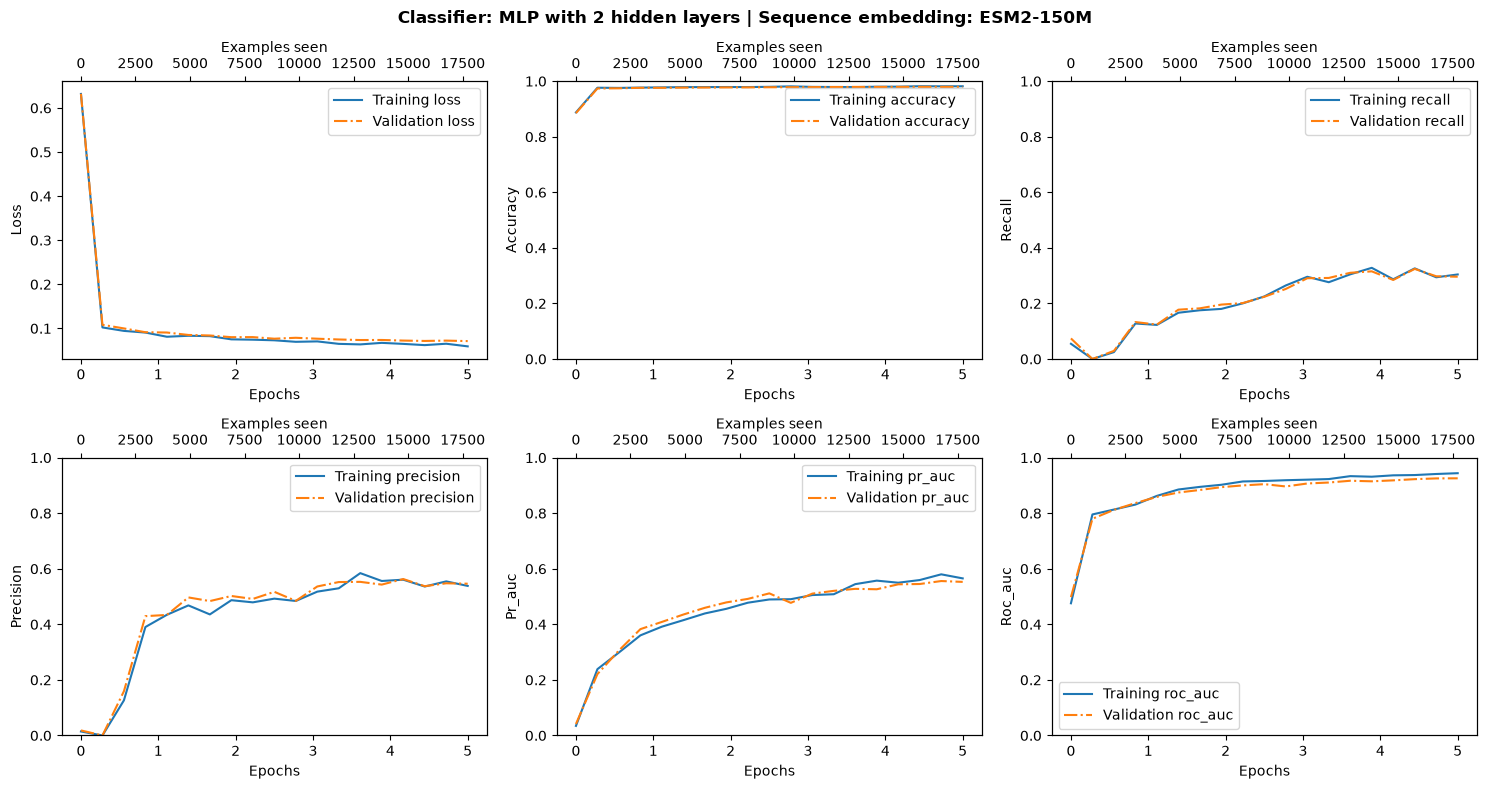

The plot is saved to /home/payman/projects/learning/compbio-bioinfx-master/protein-function-deep-learning/plots/CAFA3/metrics.png.


In [33]:
from pfdl.utils import plot_results

results_path = plot_results(
    num_epochs, *history, dataset="CAFA3", title="Classifier: MLP with 2 hidden layers | Sequence embedding: ESM2-150M")

print(f"The plot is saved to {results_path}.")

Here is the summary of our training dynamics and evaluation:

**Loss Curves**: Loss drops sharply within ~30 steps and stabilizes, showing rapid convergence without training instability. The shallow MLP quickly captures primary signals from the frozen embeddings.

**Accuracy and ROC-AUC Metrics**: Accuracy and ROC-AUC remain static; both are misleadingly inflated due to severe negative class imbalance in multilabel protein function targets. Therefore, we should not weight on these metrics in our evaluation.

**Precision/Recall and PRC-AUC Metrics**: Continuous improvements of these metrics indicate the model is still learning subtle signals. Precision rises faster than recall, meaning predictions grow more confident but remain conservative.

**Takeaway**: While main optimization occurs early, steady PRC-AUC and recall gains suggest potential headroom from extending epochs or scaling capacity of the model.

---

## **Examining Model Predictions**

Now that our model is trained, let's look at what it does well and where it struggles. We generated predictions for the whole validation set and put them side-by-side with the true labels to spot patterns:

In [34]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from pfdl.data import load_sequence_embeddings

# Load validation dataframe and extract 'EntryID' and target columns
valid_df = load_sequence_embeddings(
    store_file_prefix=str(DATA_DLFB / "protein_dataset_valid"),
    model_checkpoint=esm_checkpoint
)
valid_true_df = valid_df.filter(regex="EntryID|^GO:").set_index("EntryID")

# Compute prob, for each function across all valid examples
valid_probs = []
for batch in valid_loader:
    batch_x = jnp.asarray(batch["embedding"])
    logits = clf_model(batch_x)
    valid_probs.extend(jax.nn.sigmoid(logits))

valid_probs_df = pd.DataFrame(
    np.vstack(valid_probs), columns=valid_true_df.columns, index=valid_true_df.index
)

print("Shape of true valid dataframe:", valid_true_df.shape)
print("Shape of probs valid dataframe:", valid_probs_df.shape)

Shape of true valid dataframe: (1191, 291)
Shape of probs valid dataframe: (1191, 291)


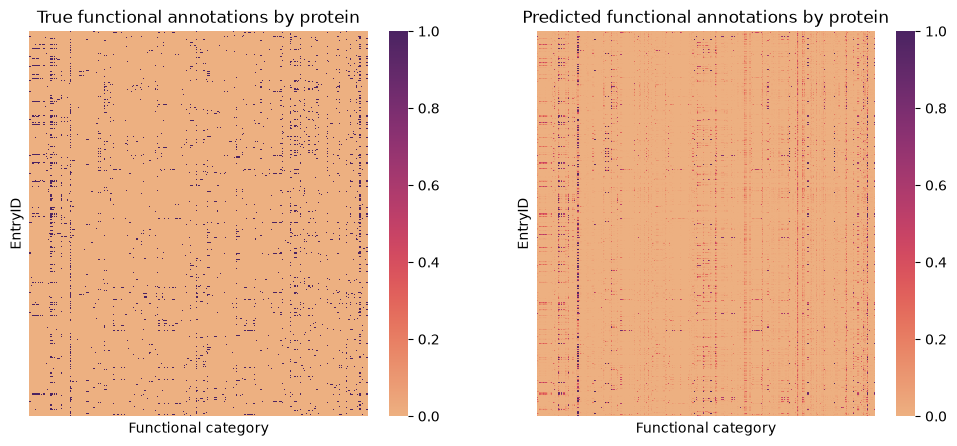

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pfdl.paths as paths

fig, axes = plt.subplots(1, 2, figsize=(12, 5), squeeze=True, sharey=True)
ax1, ax2 = axes.flatten()

sns.heatmap(
    ax=ax1,
    data=valid_true_df,
    vmin=0,
    vmax=1.0,
    xticklabels=False,
    yticklabels=False,
    cmap='flare'
)
ax1.set_xlabel("Functional category")
ax1.set_title("True functional annotations by protein")

sns.heatmap(
    ax=ax2,
    data=valid_probs_df,
    vmin=0,
    vmax=1.0,
    xticklabels=False,
    yticklabels=False,
    cmap='flare'
)

ax2.set_xlabel("Functional category")
ax2.set_title("Predicted functional annotations by protein")
fig.savefig(paths.PLOTS_DIR / "CAFA3/model_prediction_high_level.png", bbox_inches="tight");

We can summarize our findings on the plots as below:

* **Frequent functions are easy to learn:** Functions that appear often in the dataset (visible as dark vertical stripes in the true labels) are predicted accurately by the model.
* **Rare functions get missed:** Rare functions are much harder to capture. The model often misses them completely, leaving empty or blank columns in the prediction map.
* **Some functions are over-predicted:** A few functions show faint lines across almost all proteins, meaning the model is guessing them too often and creating false positives.
* **Uncertain predictions show up in the middle:** Many predictions fall in the middle range (around 0.5 probability) instead of a clear 0 or 1, showing where the model is unsure.

After this high-level visualization, let's focus on each protein's function individually:

In [36]:
from pfdl.evaluate import compute_metrics

# Compute metrics per function across all proteins
target_functions = valid_true_df.columns.values.tolist()
metrics_by_function = {}

for function in target_functions:
    metrics_by_function[function] = compute_metrics(
        valid_true_df[function].values,
        valid_probs_df[function].values,
        threshold=0.5
    )
    metrics_by_function[function].update({"Avg Appearance (%)": valid_true_df[function].mean()})

# Put together a table of metrics for each target function
# and corresponding GO descriptions
overview_valid = (
    pd.DataFrame(metrics_by_function)
    .T.merge(go_term_descriptions, left_index=True, right_on="term")
    .set_index("term")
    .sort_values("pr_auc")
    )

overview_valid

,accuracy,recall,precision,pr_auc,roc_auc,Avg Appearance (%),description
term,,,,,,,
GO:0003774,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,cytoskeletal motor activity
GO:0004222,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,metalloendopeptidase activity
GO:0004714,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,transmembrane receptor protein tyrosine kinase...
GO:0008081,0.998321,0.000000,0.000000,0.000000,0.000000,0.000000,phosphoric diester hydrolase activity
GO:0042626,0.999160,0.000000,0.000000,0.001996,0.579832,0.000840,ATPase-coupled transmembrane transporter activity
...,...,...,...,...,...,...,...
GO:0043565,0.963896,0.730159,0.910891,0.884223,0.967896,0.105793,sequence-specific DNA binding
GO:0003690,0.965575,0.731707,0.918367,0.897894,0.977049,0.103275,double-stranded DNA binding
GO:0003824,0.881612,0.790244,0.854881,0.899315,0.938647,0.344249,catalytic activity


The model’s performance varies significantly across different protein functions. For instance, it successfully identifies **G protein–coupled receptor activity (GO:0004930)** but struggles with **cytoskeletal motor activity (GO:0003774)**. These results must be interpreted carefully because rare functions have fewer validation examples, and limited training data naturally restricts the model's ability to learn. To track this, average number of proteins that carry a function is also computed (see "Avg Appearance (%)" column).

The model performance evaluation for each protein function should be considered by the following items:

* **Data Representation:** There is a strong correlation between how often a function appears in the training set and its predictive accuracy ("pr_auc"). The model simply has more opportunities to learn the "grammar" of common functions than rare ones.
* **Structural Signals:** Functions that perform well, like GPCR or kinase activity, often involve well-conserved structural motifs (e.g., transmembrane helices). These provide clear, predictable signals in the amino acid sequence that the ESM-2 embeddings can easily capture.
* **Statistical Reliability:** Metrics for underrepresented functions can be misleading; a high score might be based on only a handful of examples, while a low score might reflect data scarcity rather than the biological complexity of the task.
* **Class Imbalance:** Because most proteins lack the majority of possible functions, the data is highly skewed. A model might achieve high accuracy just by predicting "no function," making ranking-based metrics like `pr_auc` much more important for seeing real progress.

### **Thresholded and Continuous Evaluation Metrics**

Our evaluation metrics fall into two categories: thresholded and continuous:
* Precision and recall are computed from binary predictions, i.e., after applying a fixed threshold (typically >0.5) to the model’s output probabilities.
* auPRC and auROC are threshold independent. They assess how well the model ranks positive examples above negatives across all possible thresholds.

Although a bit counterintuitive, it’s entirely possible for precision and recall to be 0 while auPRC and auROC remain high (as we saw in above metrics table). This happens when the model assigns higher probabilities to the correct labels, but those probabilities never exceed the decision threshold (e.g. 0.5 in our case). In such cases, thresholded metrics show failure, while ranking-based metrics still reflect meaningful signal.

If we wanted to address this issue with the current thresholded metrics, we could lower the decision threshold, for example, to 0.2 or 0.3, to encourage more positive predictions. The threshold can be tuned automatically using metrics like the F1 score (the harmonic mean of precision and recall).

The following cell computes the optimal threshold for one of the fucntions with high auROC/auPRC but zero recall/precision:

In [37]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# protein function with zerpo
function = "GO:0016811" #hydrolase activity, acting on carbon-nitrogen (but not peptide) bonds, in linear amides

print("Function metrics using 0.5 as threshold:", 
      overview_valid.loc[function])
print("---------")

# Compute precisions, recalls, and thresholds
precisions, recalls, thresholds = precision_recall_curve(valid_true_df[function].values, valid_probs_df[function].values)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[best_idx]:.4f}")
print("---------")

adjusted_metrics = pd.Series(
    compute_metrics(
        valid_true_df[function].values,
        valid_probs_df[function].values,
        threshold=best_threshold
        )
)
print("Function metrics using adjusted threshold:",
      adjusted_metrics)

Function metrics using 0.5 as threshold: accuracy                                                       0.991604
recall                                                              0.0
precision                                                           0.0
pr_auc                                                         0.140416
roc_auc                                                        0.888908
Avg Appearance (%)                                             0.008396
description           hydrolase activity, acting on carbon-nitrogen ...
Name: GO:0016811, dtype: object
---------
Optimal Threshold: 0.0179
Max F1-Score: 0.2500
---------
Function metrics using adjusted threshold: accuracy     0.979849
recall       0.400000
precision    0.181818
pr_auc       0.140416
roc_auc      0.888908
dtype: float64


As expected, both of thresholded recall and precision metrics are improved while continueous metircs are not changed.

Earlier, we hypothesized that model performance improves as the number of training examples for a given function increases. Let’s examine this relationship directly: do higher class frequencies in the training data correlate with better predictive performance on the validation set?

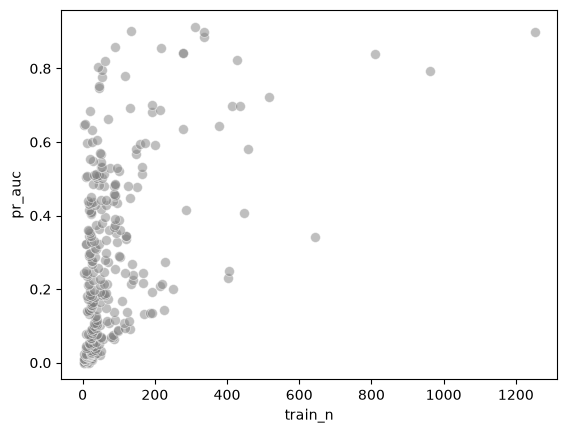

In [38]:
overview_valid = overview_valid.merge(
    pd.DataFrame(train_df[target_functions].sum(), columns=["train_n"]),
    left_index=True,
    right_index=True
)

fig = sns.scatterplot(data=overview_valid, x="train_n", y="pr_auc", alpha=0.5, s=50, color="grey")

The plot shows a direct correlation between how often a protein function appears in the training set and how accurately the model predicts it (auPRC). This reflects a common machine learning reality: models excel on well-represented classes but struggle with "rare" functions due to class imbalance, a lack of sufficient examples rather than inherent biological difficulty.

To determine if a score like 0.8 is actually meaningful, it must be compared against a baseline to ensure the model is learning real patterns rather than just guessing based on frequency. In next section, we will explore this.

## **Evaluating Model Usefulness**

To ground our evaluation, we’ll compare our model against two simple baselines:

* **Coin flip**: For each protein function, randomly predict 0 or 1 with equal probability. This gives us a baseline for total ignorance.

* **Proportional guessing**: Predict 1 for each function with probability equal to its frequency in the training set. This reflects prior class distribution knowledge, but without any learning.

These baselines help contextualize the model’s performance. If our trained model doesn’t outperform these simple heuristics, it’s a sign that it may not have learned meaningful structure from the data. We evaluate the baselines in exactly the same way as our model (by computing per-protein metrics and averaging them):

In [39]:
from pfdl.evaluate import make_coin_flip_predictions, make_proportional_predictions

prediction_methods = {
  "coin_flip_baseline": make_coin_flip_predictions(valid_true_df, target_functions),
  "proportional_guess_baseline": make_proportional_predictions(
    valid_true_df, train_df, target_functions
  ),
  "model": valid_probs_df,
}

metrics_by_method = {}
for method, preds_df in prediction_methods.items():
  metrics_by_method[method] = pd.DataFrame(
    [
      compute_metrics(valid_true_df.iloc[i], preds_df.iloc[i])
      for i in range(len(valid_true_df))
    ]
  ).mean()

pd.DataFrame(metrics_by_method)

,coin_flip_baseline,proportional_guess_baseline,model
accuracy,0.499981,0.955482,0.980717
recall,0.512400,0.098036,0.287670
precision,0.024128,0.082286,0.535113
pr_auc,0.025786,0.040804,0.544238
roc_auc,0.506131,0.537442,0.926321


The model significantly outperforms both random and frequency-based baselines, particularly in precision, auPRC, and auROC. While frequency-based guessing yields a deceptively high accuracy due to class imbalance, the trained model leverages actual sequence features to make more informed predictions.

Currently, the model is "conservative but accurate", it shows high precision but modest recall, meaning it effectively avoids "false alarms" but still misses many true positives. This behavior can be tuned for specific applications by lowering the decision threshold (e.g., from 0.5 to 0.2) to improve recall and capture more functional annotations. Let's recompute the metrics using a lower threshold:

In [40]:
metrics_by_method = {}
for method, preds_df in prediction_methods.items():
  metrics_by_method[method] = pd.DataFrame(
    [
      compute_metrics(valid_true_df.iloc[i], preds_df.iloc[i], threshold=0.2)
      for i in range(len(valid_true_df))
    ]
  ).mean()

pd.DataFrame(metrics_by_method)

,coin_flip_baseline,proportional_guess_baseline,model
accuracy,0.499981,0.955482,0.975659
recall,0.512400,0.098036,0.491377
precision,0.024128,0.082286,0.462084
pr_auc,0.025786,0.040804,0.544238
roc_auc,0.506131,0.537442,0.926321


We can see that our recall is almost doubled but precision slightly decreased. This is because we lowered the threshold for all functions. In an ideal case, thresholds should be adjusted for each function separately.

Next, we break down the model’s strengths and weaknesses by individual protein function (top 20 best performing) and compare performance against both baselines. This allows us to see which specific functions the model predicts well and where it struggles:

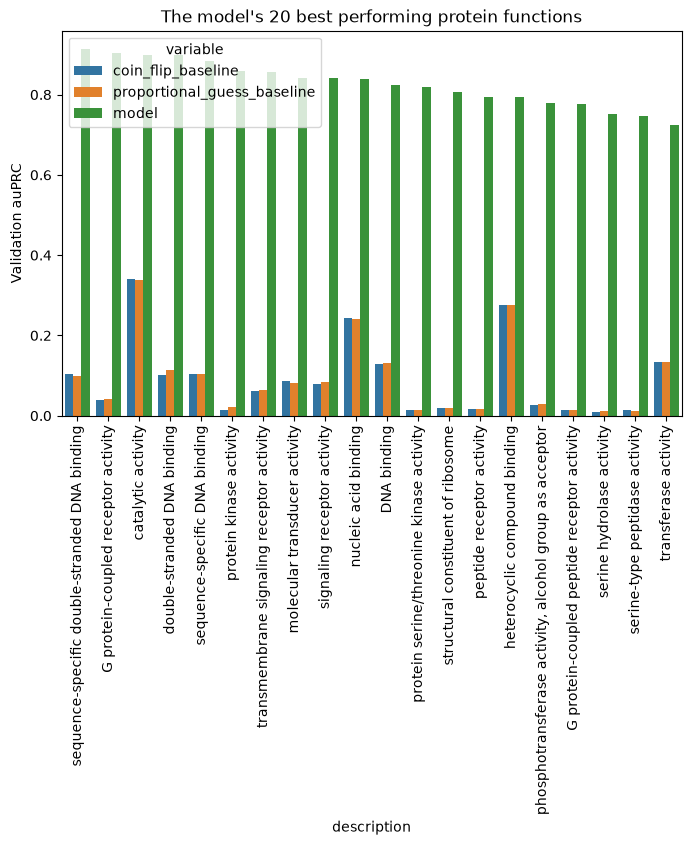

In [41]:
import pfdl.paths as paths

auprc_by_function = {}

for method, preds_df in prediction_methods.items():
    metrics_by_function = {}

    for function in target_functions:
        metrics_by_function[function] = compute_metrics(
        valid_true_df[function], preds_df[function]
    )

    auprc_by_function[method] = (
        pd.DataFrame(metrics_by_function)
        .T.merge(go_term_descriptions, left_index=True, right_on="term")
        .set_index("term")
        .sort_values("pr_auc", ascending=False)
        )["pr_auc"].to_dict()

best_performing = (
    pd.DataFrame(auprc_by_function)
    .merge(go_term_descriptions, left_index=True, right_on="term")
    .set_index("term")
    .sort_values("model", ascending=False)
    .head(20)
    .melt("description")
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x="description",
    y="value",
    hue="variable",
    data=best_performing,
)
ax.set_title("The model's 20 best performing protein functions")
ax.set_ylabel("Validation auPRC")
plt.xticks(rotation=90);
fig.savefig(paths.PLOTS_DIR / "CAFA3/model_usefullness.png", bbox_inches="tight")

The model excels at predicting membrane and signaling functions, like GPCR and kinase activity, because they often rely on highly conserved structural motifs such as transmembrane helices or catalytic domains. These well-defined biochemical markers provide a much stronger "sequence-level signal" than more context-heavy roles. Overall, these findings prove the model can detect genuine biological patterns and substantially outperform basic heuristics.

----

## **Conducting a Final Check on the Test Set**

We must not touch the test set until we've fully finalized our model, including all hyperparameters, architectures, and training choices. Evaluating on the test set repeatedly can lead to overly optimistic results and undermine the validity of our findings.

In [42]:
from pfdl.evaluate import calc_classification_metrics_loader

eval_metrics = []

for split in ["valid", "test"]:

    split_metric = calc_classification_metrics_loader(clf_model, dataset_splits[split])
    eval_metrics.append(
        {"split": split, **split_metric}
    )
pd.DataFrame(eval_metrics)

,split,accuracy,recall,precision,pr_auc,roc_auc
0,valid,0.980670,0.286161,0.532923,0.542984,0.925551
1,test,0.981403,0.303205,0.540047,0.554796,0.934177


The test set performance closely aligns with the validation results, indicating strong generalization. Because we performed minimal tuning, we avoided the common issue of test-score degradation caused by overfitting to the validation set during development. These final, held-out metrics provide the most reliable estimate of real-world performance and are the standard for external reporting.

## **Summary**

In this notebook, we used the pre-trained ESM-2 language model to generate sequence representations for human proteins. After training a downstream classifier (a simple neural net) for functional annotation, we analyzed key modeling challenges, including severe class imbalance and the nuances of interpreting evaluation metrics like AUPRC.

There are several strategies to improve performance. We will review these strategies and implement them in subsequent notebooks.